In [1]:
import os

# os.environ["CUDA_VISIBLE_DEVICES"] = "0,1,2,3"  
os.environ["CUDA_VISIBLE_DEVICES"] = "0,1"  
from torch import nn

from tqdm import tqdm
import numpy as np
 
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer  
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt  
import torch.nn.functional as F
import gc

import sys
sys.path.append('..')
from tqdm import tqdm

import JCBScope_utils
import JacobianScopes

# Move to GPU with optimal dtype
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
# device = "cpu"

from matplotlib.colors import Normalize as Norm, LogNorm as Log_Norm

### Text-based visualization with colored boxes (like highlighted sentence)
from IPython.display import HTML, display
import matplotlib.colors as mcolors
import matplotlib as mpl


/home/jl3499/conda/LLM1/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/jl3499/conda/LLM1/lib/python3.12/site-packages/transformers/utils/hub.py:110: FutureWarning: Using `TRANSFORMERS_CACHE` is deprecated and will be removed in v5 of Transformers. Use `HF_HOME` instead.
  warnings.warn(


### Set input strings

In [2]:
front_pad = 2
back_pad = 0

system_prompt = ""

In [3]:
example_sentence_list = [
    "Italian: Buon pomeriggio, i miei colleghi ricercatori. English: Good afternoon, my fellow researchers",
    "German: Dies ist ein Aufsatz über kausale Zuschreibung. English: This is a paper on causal attribution",
    "French: Nous l'appelons lentille jacobienne. English: We call it Jacobian Scope",
]

In [4]:
from pathlib import Path
import json

lambada_path = Path("../data/lambada_prompts_1000.json")
with lambada_path.open("r", encoding="utf-8") as f:
    lambada_prompts = json.load(f)

# sentence_list = [ex["text"] for ex in lambada_prompts[90:100]]
sentence_list = [ex["text"] for ex in lambada_prompts[:100]]

### Skip delimiters for time-series data
skip_delimiters = False

### Load models

In [5]:
# Deep clean CUDA GPU memory
torch.cuda.empty_cache()
torch.cuda.ipc_collect()
gc.collect()  



108

In [6]:
# Load the tokenizer and model

model_name = "meta-llama/Llama-3.2-1B"
# model_name = "meta-llama/Llama-3.2-3B"
# model_name = "meta-llama/Llama-2-7b-chat-hf"

if device == "cpu":
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    model = AutoModelForCausalLM.from_pretrained(model_name)
    model = model.to(device)
else:
    tokenizer = AutoTokenizer.from_pretrained(model_name, device_map="auto")
    model = AutoModelForCausalLM.from_pretrained(model_name, device_map="auto")
    
model.eval()

LlamaForCausalLM(
  (model): LlamaModel(
    (embed_tokens): Embedding(128256, 2048)
    (layers): ModuleList(
      (0-15): 16 x LlamaDecoderLayer(
        (self_attn): LlamaAttention(
          (q_proj): Linear(in_features=2048, out_features=2048, bias=False)
          (k_proj): Linear(in_features=2048, out_features=512, bias=False)
          (v_proj): Linear(in_features=2048, out_features=512, bias=False)
          (o_proj): Linear(in_features=2048, out_features=2048, bias=False)
        )
        (mlp): LlamaMLP(
          (gate_proj): Linear(in_features=2048, out_features=8192, bias=False)
          (up_proj): Linear(in_features=2048, out_features=8192, bias=False)
          (down_proj): Linear(in_features=8192, out_features=2048, bias=False)
          (act_fn): SiLUActivation()
        )
        (input_layernorm): LlamaRMSNorm((2048,), eps=1e-05)
        (post_attention_layernorm): LlamaRMSNorm((2048,), eps=1e-05)
      )
    )
    (norm): LlamaRMSNorm((2048,), eps=1e-05)
    (ro

In [7]:
def fisher_eigvals_for_sentence(sentence: str):
    """Compute Fisher eigenvalues for a single input sentence.

    Uses the same model, tokenizer, and system prompt as above but is self-contained
    so it can be called repeatedly for different sentences.
    """
    # Tokenize with padding and optional system prompt
    sys_prompt_tokens = tokenizer(system_prompt, add_special_tokens=False)["input_ids"]
    sys_token_len = len(sys_prompt_tokens)

    bos_token_id = tokenizer.bos_token_id if tokenizer.bos_token_id is not None else tokenizer.cls_token_id
    eos_token_id = tokenizer.eos_token_id if tokenizer.eos_token_id is not None else tokenizer.sep_token_id

    input_ids_list = []
    if bos_token_id is not None:
        input_ids_list += [bos_token_id] * front_pad

    input_ids_list += sys_prompt_tokens
    input_ids_list += tokenizer(sentence, add_special_tokens=False)["input_ids"]

    if eos_token_id is not None:
        input_ids_list += [eos_token_id] * back_pad

    input_ids = torch.tensor([input_ids_list], dtype=torch.long).to(model.device)
    attention_mask = torch.ones_like(input_ids)

    decoded_tokens = [tokenizer.decode(token_id.item(), skip_special_tokens=True) for token_id in input_ids[0]]

    # Choose which token positions to include in the gradients / Fisher
    if skip_delimiters:
        grad_idx = [idx for idx in range(front_pad + sys_token_len, len(decoded_tokens), 2)]
    else:
        grad_idx = [idx for idx in range(front_pad + sys_token_len, len(decoded_tokens), 1)]

    embedding_layer = model.get_input_embeddings()
    d_model = embedding_layer.embedding_dim

    residual = nn.Parameter(torch.zeros(len(grad_idx), d_model, device=model.device))
    presence = torch.ones(len(decoded_tokens), 1, device=model.device)

    forward_pass = JCBScope_utils.customize_forward_pass(
        model, residual, presence, input_ids, grad_idx, attention_mask
    )

    loss_position = grad_idx[-1] - 1

    # Forward pass to obtain logits at the target position
    loss, logits = forward_pass(loss_position=loss_position, hidden_norm_as_loss=True)

    fisher_hidden_from_logits_and_W = JacobianScopes.fisher_hidden_from_logits_and_W
    lm_head = JCBScope_utils.get_lm_head(model)
    W = lm_head.weight.to(model.device)  # [V, d_model]

    t = loss_position
    logits_t = logits[t].to(model.device)  # [V]

    with torch.no_grad():
        Fx = fisher_hidden_from_logits_and_W(logits_t, W, chunk_size=8192)  # [d_model, d_model]

        orig_device = Fx.device
        Fx_cpu = Fx.float().contiguous().cpu()
        U_full, eigvals, _ = torch.linalg.svd(Fx_cpu)
        eigvals = eigvals.numpy()
        U_full = U_full.to(orig_device)

    return eigvals




In [8]:
# Compute and plot cumulative explained fraction for each sentence
cumfracs_per_sentence = []
eigs_per_sentence = []

for sent in tqdm(sentence_list, desc="Processing sentences"):
    eigvals = fisher_eigvals_for_sentence(sent)
    eigvals_desc = np.sort(eigvals)[::-1]
    total = eigvals_desc.sum()
    cumfrac = np.cumsum(eigvals_desc) / total if total > 0 else np.zeros_like(eigvals_desc)
    cumfracs_per_sentence.append(cumfrac)
    eigs_per_sentence.append(eigvals_desc)

Processing sentences: 100%|██████████| 100/100 [02:07<00:00,  1.28s/it]


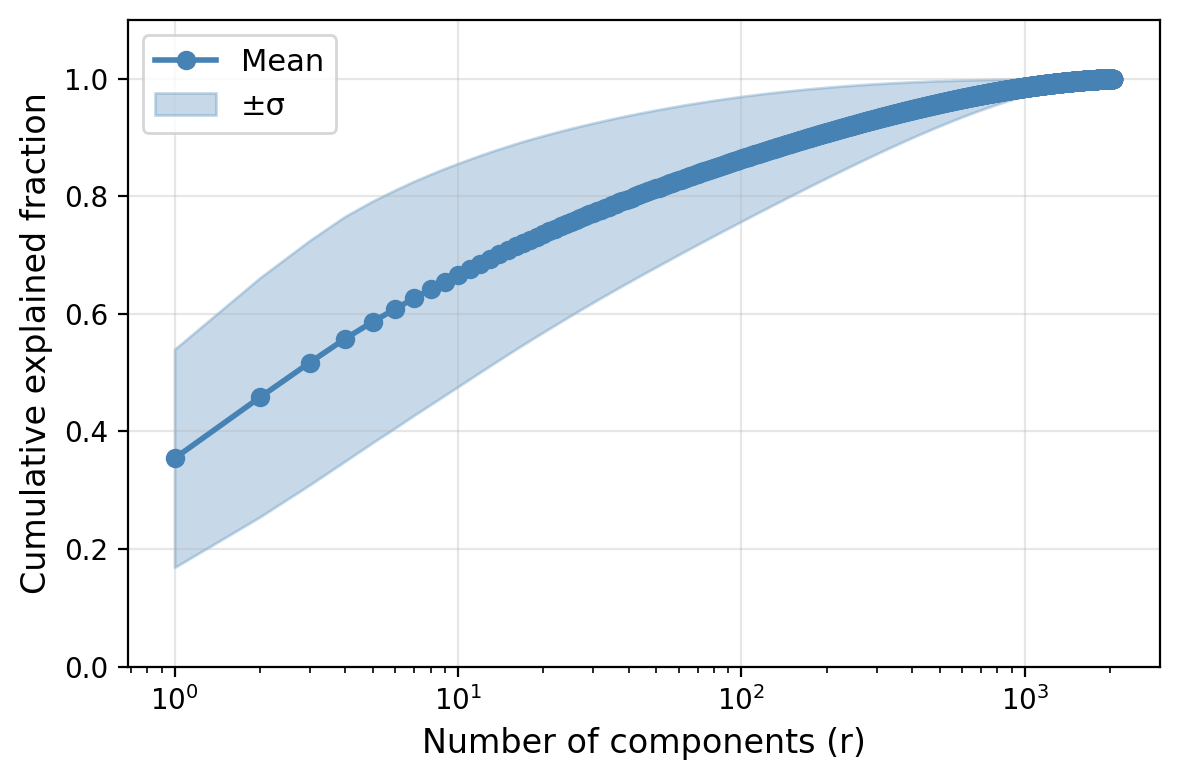

In [24]:
# Assume all eigenvalue spectra have the same length (dimension of hidden state)
if len(cumfracs_per_sentence) > 0:
    fig, ax = plt.subplots(1, 1, figsize=(6, 4), dpi=200)

    min_len = min(len(c) for c in cumfracs_per_sentence)
    r = np.arange(1, min_len + 1)
    spectra_matrix = np.stack([c[:min_len] for c in cumfracs_per_sentence])  # [N, min_len]
    mean_spectrum = spectra_matrix.mean(axis=0)
    std_spectrum = spectra_matrix.std(axis=0)

    ax.plot(r, mean_spectrum, color="steelblue", linewidth=2, label="Mean", marker="o")
    ax.fill_between(r, mean_spectrum - std_spectrum, mean_spectrum + std_spectrum,
                    color="steelblue", alpha=0.3, label="±σ")

    ax.set_xlabel("Number of components (r)", fontsize=12)
    ax.set_ylabel("Cumulative explained fraction", fontsize=12)
    ax.grid(True, alpha=0.3)
    ax.set_ylim(0, 1.1)
    ax.set_xscale("log")
    ax.legend(fontsize=11)
    plt.tight_layout()
    plt.show()
    

In [21]:
print(f"x axis range: {ax.get_xlim()}")

x axis range: (np.float64(0.6830201283771977), np.float64(2998.447505296642))


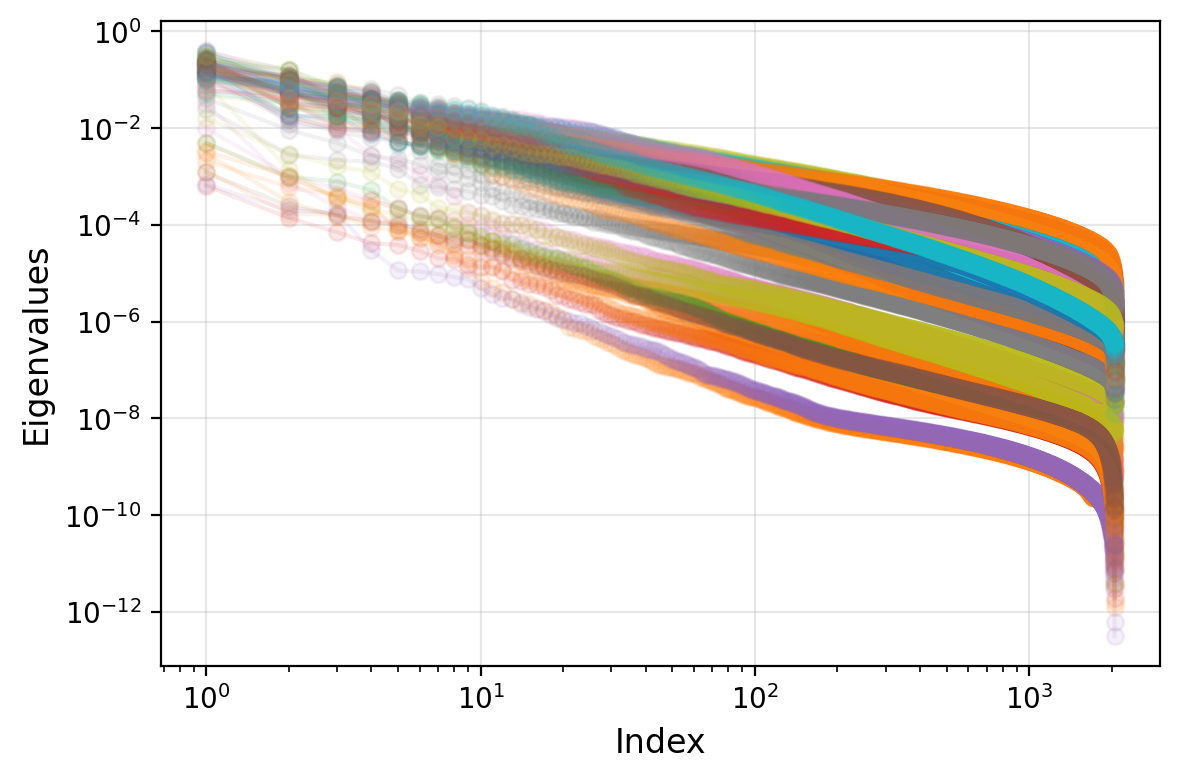

In [10]:



# Assume all eigenvalue spectra have the same length (dimension of hidden state)
if len(eigs_per_sentence) > 0:
    r = np.arange(1, len(eigs_per_sentence[0]) + 1)

    fig, ax = plt.subplots(1, 1, figsize=(6, 4), dpi=200)

    for sent, eigs in zip(sentence_list, eigs_per_sentence):
        # Use a short, human-readable label for the legend
        # short_label = sent.split("English")[0].strip()
        short_label = sent[:10]
        ax.plot(r, eigs, marker="o", linewidth=1.5, alpha=0.1, label=short_label+"...")

    ax.set_xlabel("Index", fontsize=12)
    ax.set_ylabel("Eigenvalues", fontsize=12)
    ax.grid(True, alpha=0.3)
    # ax.set_ylim(-0.10, 1.1)
    ax.set_xscale("log")
    ax.set_yscale("log")
    # ax.legend()
    plt.tight_layout()
    plt.show()